In [2]:
import os
import shutil
import pandas as pd
from cleanvision import Imagelab

c:\Users\shubh\Desktop\Job\I2V_project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Initialize and run audit

In [3]:
data_path = "../data/vehicle_dataset/train"
imagelab = Imagelab(data_path=data_path)
imagelab.find_issues()

Reading images from c:/Users/shubh/Desktop/Job/I2V_project/notebooks/../data/vehicle_dataset/train
Checking for dark, light, odd_aspect_ratio, low_information, exact_duplicates, near_duplicates, blurry, grayscale, odd_size images ...


Computing hashes: 100%|██████████| 2719/2719 [00:17<00:00, 159.87it/s]


Issue checks completed. 143 issues found in the dataset. To see a detailed report of issues found, use imagelab.report().


## 2. Get the issues summary

In [4]:
issue_df = imagelab.issues
issue_cols = [col for col in issue_df.columns if col.endswith("_issue")]
clean_images_df = issue_df[issue_df[issue_cols].sum(axis=1) == 0]
print(f"Original images: {len(issue_df)}")
print(f"Clean images: {len(clean_images_df)}")
print(f"Images removed: {len(issue_df) - len(clean_images_df)}")

Original images: 2719
Clean images: 2581
Images removed: 138


## 3. Vehicle Class Distribution

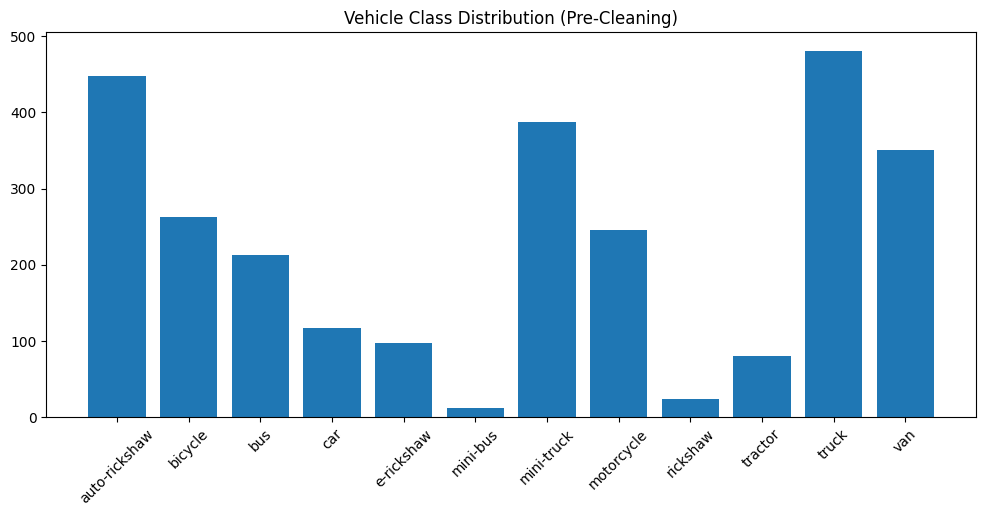

In [10]:
import matplotlib.pyplot as plt

# Count images per class
class_counts = {cls: len(os.listdir(os.path.join(data_path, cls))) for cls in os.listdir(data_path)}
plt.figure(figsize=(12,5))
plt.bar(class_counts.keys(), class_counts.values())
plt.title("Vehicle Class Distribution (Pre-Cleaning)")
plt.xticks(rotation=45)
plt.show()

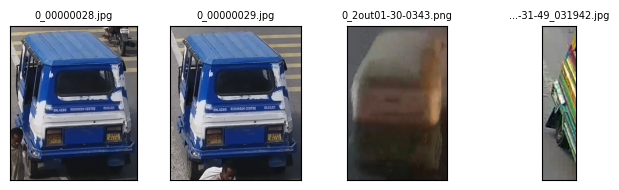

In [6]:

issue_images = issue_df[issue_df[issue_cols].sum(axis=1) > 0].index[:4]
imagelab.visualize(image_files=list(issue_images))